In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [3]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [4]:
# task_id = config['dataset_kwargs']['task_id']
# task_id
config['landmark']

True

In [5]:
task_id = 'aids_ds'

In [6]:
model = DeepLambdaSA(config, seed=42)

In [7]:
train_gen, _ = model.get_train_test()

In [8]:
def get_masks_initstate_ibs(h, n):
    aux = jnp.zeros(h).at[0].set(1)
    return jnp.tile(aux, n)

In [9]:
%%time

num_exps = 1
sizes = [.2]
size = sizes[0]
tgt_lrs = [.0001, .001, .005, .01, .05]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = tgt_lr
        
        # print(".", end="")
        print('tgt_lr = {}'.format(tgt_lr), end=", ")
        
        
        # Landmarking.
        config['lambda_'] = 1.0
        model = DeepLambdaSA(config, seed=fold)
        print('model_lambda', model.lambda_)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        print(beta)
        scores = score(beta, seqs[:,0])
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        print('---')
        print('model_lambda', model.lambda_)
        print(beta)
        scores = score(beta, seqs[:,0])
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

tgt_lr = 0.0001, model_lambda 1.0


KeyboardInterrupt: 

In [37]:
bs_0

array([[0.22316402, 0.22316402, 0.22316402, 0.22316402, 0.22316402]])

In [38]:
bs_1

array([[0.21260026, 0.21260026, 0.21260026, 0.21260026, 0.21260026]])

Text(0.5, 0, 'Test size proportion')

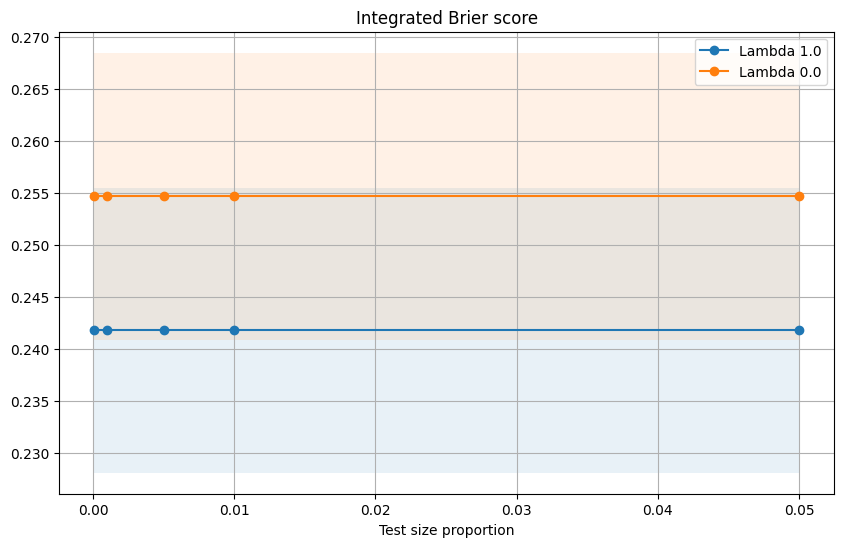

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Lambda 1.0"), (res2_lm, "Lambda 0.0")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(tgt_lrs, mean, marker="o", label=label)
    ax.fill_between(tgt_lrs, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

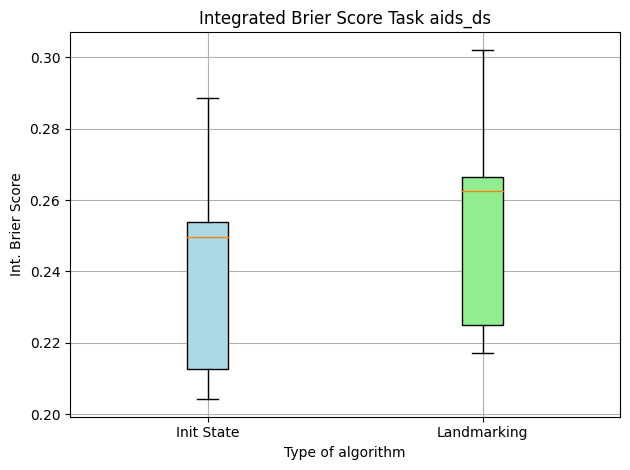

In [10]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

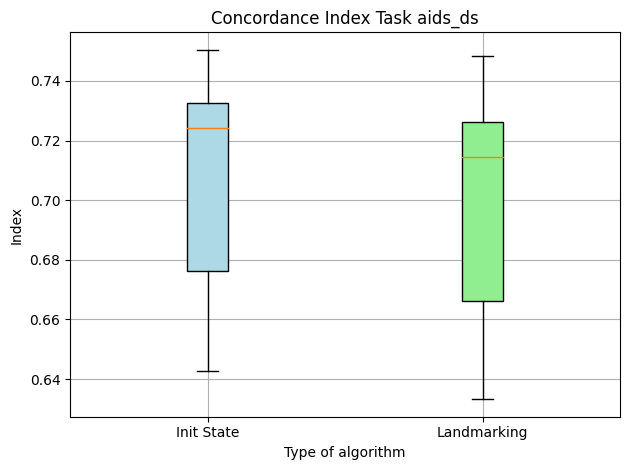

In [11]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [15]:
config['target_lr'] = 0
config['num_epochs'] = 20

In [16]:
model = DeepLambdaSA(config, seed=42)

In [17]:
model.state.params

{'cox_linear_model': {'beta': Array([0., 0., 0., 0., 0.], dtype=float32),
  'alpha': Array([0., 0., 0., 0., 0.], dtype=float32)}}

In [20]:
model.state.tgt_params

{'cox_linear_model': {'alpha': Array([0., 0., 0., 0., 0.], dtype=float32),
  'beta': Array([0., 0., 0., 0., 0.], dtype=float32)}}

In [18]:
losses = model.train()

In [14]:
model.state.params  # Lambda 1

{'cox_linear_model': {'alpha': Array([-0.19571827, -0.18767777, -0.15923883, -0.16001163, -0.16322109],      dtype=float32),
  'beta': Array([-0.1918764 , -0.18773696, -0.19214343, -0.19260943, -0.18587291],      dtype=float32)}}

In [19]:
model.state.params  # Lambda 0

{'cox_linear_model': {'alpha': Array([-0.19577634, -0.05101885,  0.10717901,  0.09314578,  0.09085093],      dtype=float32),
  'beta': Array([-0.18432385, -0.17442417, -0.18536885, -0.18591842, -0.16725823],      dtype=float32)}}

In [71]:
model.state.params  # Lambda 0.1

{'cox_linear_model': {'alpha': Array([-0.19569013, -0.1966354 , -0.19908774, -0.2004318 , -0.20057881],      dtype=float32),
  'beta': Array([-0.19566303, -0.19422923, -0.1961574 , -0.19590312, -0.18809639],      dtype=float32)}}

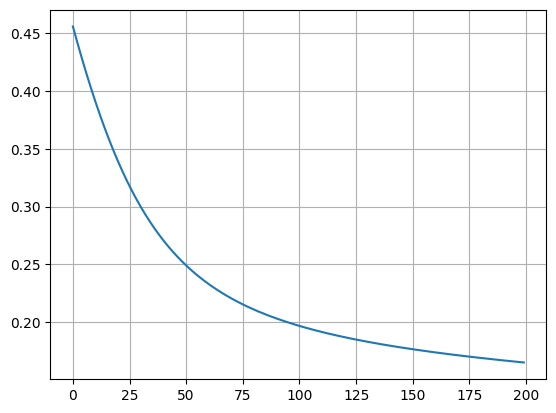

In [35]:
plt.plot(losses)
plt.grid()
plt.show()

In [128]:
surv = model.survival_curve(seqs)

In [131]:
model.integrated_brier_score(surv[:, 0], ts, cs, jnp.ones_like(ts))

Array(0.09166312, dtype=float32)

In [130]:
surv_, ts_, cs_, ms_ = unroll_time(surv, ts, cs, ms, model.horizon)
assert len(ms_is_) == len(ts_)
model.integrated_brier_score(surv_, ts_, cs_, ms_is_)

Array(0.0924031, dtype=float32)

In [122]:
ms_is_.sum()

Array(93., dtype=float32)

In [126]:
jnp.ones_like(ts).sum()

Array(93, dtype=int32)

In [127]:
surv

Array([[[1.        , 0.65273726, 0.4343406 , 0.31507546, 0.24796921,
         0.19624844],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386]],

       [[1.        , 0.8581503 , 0.74219763, 0.6640936 , 0.6125853 ,
         0.56622034],
        [1.        , 0.8320324 , 0.69871646, 0.61096036, 0.5540632 ,
         0.50369126],
        [1.        , 0.8643606 , 0.7527203 , 0.67711806, 0.627063  ,
         0.58183277],
        [1.        , 0.9270313 , 0.862841  , 0.817081  , 0.7856249 ,
         0.756141  ],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386]],

       [[1.        , 0.6794405 , 0.46990314, 0.35180593, 0.28371558,
         0.229967